In [1]:
from cuda_cqed.sim import Sim
# import gpu_odes.HatGPUODE_D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

In [45]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('wa', 6.0e9*2*pi)
sim.add_param('wb', 3.8e9*2*pi)
sim.add_param('sqrtka', np.sqrt(5e6*2*pi)) # in MHz
sim.add_param('sqrtkb', np.sqrt(50e6*2*pi)) # in MHz
sim.add_param('gab', 10e6 * 2 * np.pi)
sim.add_param('gbc', 10e6 * 2 * np.pi)
sim.add_param('g3', 50e6 * 2 * np.pi)
sim.add_param('g4', 0e6 * 2 * np.pi)
sim.add_param('gr', 1e6 * 2 * np.pi)
sim.add_param('amplR',  20000)
sim.add_param('amplC1', 5)
sim.add_paramsweep('wR', 5.8e9 * 2 * np.pi, 6.2e9 * 2 * np.pi, 201, is_excitation=True)
sim.add_paramsweep('wC1', -2.6e9*2*np.pi,  -1.8e9*2*np.pi, 201)
sim.add_param('rampR', 1e-9)
sim.add_param('rampC1', 1e-9)
sim.add_param('startR', 5e-9)
sim.add_param('stopR', 200e-9)
sim.add_param('startC1', 5e-9)
sim.add_param('stopC1', 200e-9)
sim.add_param('phaseR', -np.pi / 4)
sim.add_param('phaseC1', np.pi / 3)

Rpulse = sim.make_pulse('wR', 'amplR', 'phaseR', 'startR', 'stopR', 'rampR')
C1pulse = sim.make_pulse('wC1', 'amplC1', 'phaseC1', 'startC1', 'stopC1', 'rampC1')

sim.add_EOM('bin', C1pulse)
sim.add_EOM('ain', Rpulse)

sim.add_EOM('a', '-1j*wa*a - 1j*gab*b*conjugate(bin) - ain*sqrtka - (sqrtka**2/2)*a')
sim.add_EOM('b', '-1j*wb*b - 1j*gab*a*bin - 1j*b*g4*abs(b)**2 - bin*sqrtkb - (sqrtkb**2/2)*b ')
sim.set_solve_type('decimate')

sim.specify_time(pts_per_cycle=20, num_cycles=1000, d_factor=1)

sim.validate()

Recent change to specify_time(), check implementation
Simulation validation success!


there's a bug, where the size of different sweeps get mixed up, so you can only run square sweeps

Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


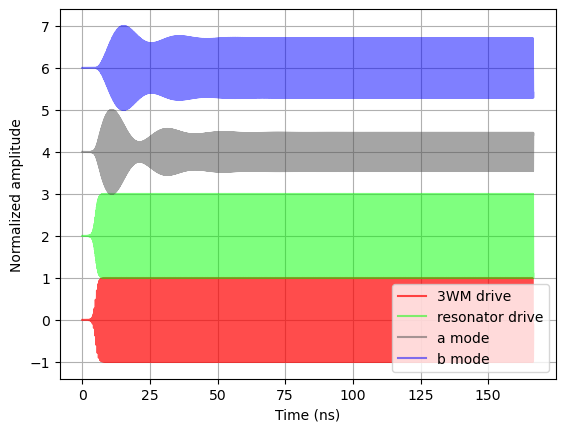

In [46]:
x, t = sim.quick_trace()

plt.figure(1)
plt.clf()
plt.plot(t*1e9, x[0,:]/np.max(x[0,:]),color=(1,0,0,0.7),label='3WM drive')
plt.plot(t*1e9, x[2,:]/np.max(x[2,:])+2,color=(0,1,0,0.5),label='resonator drive')
plt.plot(t*1e9, x[4,:]/np.max(x[4,:])+4,color=(0.3,0.3,0.3,0.5),label='a mode')
plt.plot(t*1e9, x[6,:]/np.max(x[6,:])+6,color=(0,0,1,0.5),label='b mode')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()
plt.show()

In [47]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|███████████████████████████████████████████████████████████████████████████| 20000/20000 [00:20<00:00, 992.38it/s]


 
...finished GPU solve!


In [48]:
Id = I.copy()
Qd = Q.copy()
td = t.copy()

In [49]:
ain = Id[2,:]+1j*Qd[2,:]
binn = Id[0,:]+1j*Qd[0,:]
a = Id[4,:]+1j*Qd[4,:]
b = Id[6,:]+1j*Qd[6,:]

aout = ain + sim.param_dict['sqrtka']*a

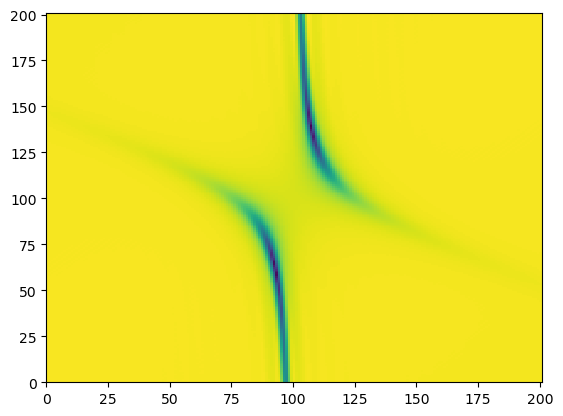

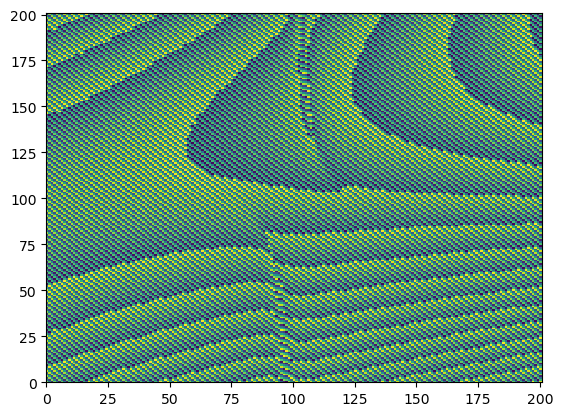

In [85]:
steady_state_aout = np.mean(np.abs(aout[:,:,np.shape(td)[-1]//2:]), axis=-1)

plt.pcolor(np.abs(steady_state_aout).transpose())
plt.show()
plt.pcolor(np.angle(aout[:,:,-1]*np.exp(1j*sim.paramsweep_dict['wR']*t[0,0,-1])).transpose())
plt.show()

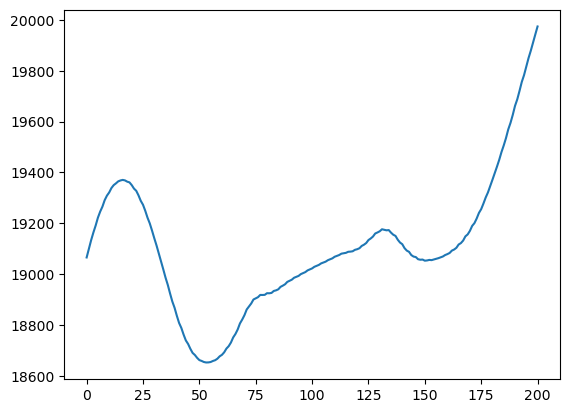

In [51]:
mag = np.abs(steady_state_aout).transpose()
plt.plot(mag[:,99])
plt.show()

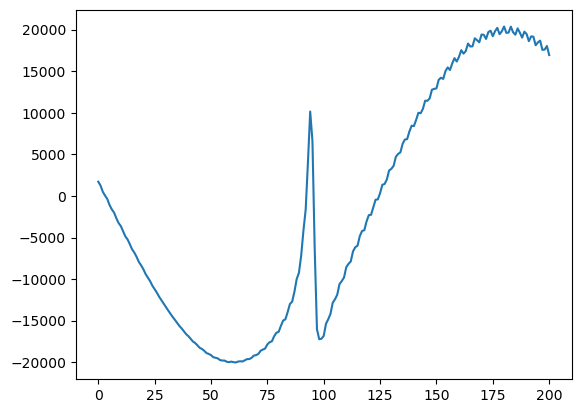

In [91]:
plt.plot(np.real(aout[:,35,-1]*np.exp(1j*sim.paramsweep_dict['wR']*t[0,0,-1])))
plt.show()

In [75]:
np.exp(sim.paramsweep_dict['wR']*t[0,0,-1]

array([6276.90212187, 6279.06657088, 6281.23101989, 6283.3954689 ,
       6285.5599179 , 6287.72436691, 6289.88881592, 6292.05326493,
       6294.21771393, 6296.38216294, 6298.54661195, 6300.71106096,
       6302.87550996, 6305.03995897, 6307.20440798, 6309.36885699,
       6311.53330599, 6313.697755  , 6315.86220401, 6318.02665302,
       6320.19110202, 6322.35555103, 6324.52000004, 6326.68444905,
       6328.84889805, 6331.01334706, 6333.17779607, 6335.34224508,
       6337.50669408, 6339.67114309, 6341.8355921 , 6344.00004111,
       6346.16449011, 6348.32893912, 6350.49338813, 6352.65783714,
       6354.82228614, 6356.98673515, 6359.15118416, 6361.31563317,
       6363.48008217, 6365.64453118, 6367.80898019, 6369.9734292 ,
       6372.1378782 , 6374.30232721, 6376.46677622, 6378.63122523,
       6380.79567423, 6382.96012324, 6385.12457225, 6387.28902126,
       6389.45347026, 6391.61791927, 6393.78236828, 6395.94681729,
       6398.11126629, 6400.2757153 , 6402.44016431, 6404.60461